In [69]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.graphics.regressionplots import influence_plot
import yfinance as yf
import requests
from io import StringIO
import time
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (12, 8)

In [70]:
dangcem = pd.read_csv("/content/DANGCEM Historical Data.csv", parse_dates=True, index_col="Date")
dangcem.head()

,Price,Open,High,Low,Vol.,Change %
Date,,,,,,
01/06/2026,"1,180.00","1,180.00","1,180.00","1,180.00",950.64K,0.00%
29/05/2026,"1,180.00","1,180.00","1,180.00","1,180.00",843.91K,0.00%
28/05/2026,"1,180.00","1,180.00","1,180.00","1,180.00",437.82K,0.00%
26/05/2026,"1,180.00","1,180.00","1,180.00","1,180.00",437.82K,0.00%
25/05/2026,"1,180.00","1,180.00","1,180.00","1,180.00",1.38M,0.00%


In [71]:
gtco = pd.read_csv("/content/GTCO Historical Data.csv", parse_dates=True, index_col="Date")
gtco.head()

,Price,Open,High,Low,Vol.,Change %
Date,,,,,,
01/06/2026,136.00,137.00,137.0,135.85,27.67M,-0.73%
29/05/2026,137.00,140.00,141.5,137.00,21.66M,-2.14%
28/05/2026,140.00,144.35,140.0,140.00,13.12M,0.00%
26/05/2026,140.00,144.35,144.0,140.00,13.12M,-3.01%
25/05/2026,144.35,145.00,145.0,144.30,19.64M,-0.45%


In [72]:
usdngn = pd.read_csv("/content/USD_NGN Historical Data.csv", parse_dates=True, index_col="Date")
usdngn.head()

,Price,Open,High,Low,Vol.,Change %
Date,,,,,,
01/06/2026,"1,369.670","1,370.900","1,374.065","1,366.975",NaN,-0.16%
29/05/2026,"1,371.885","1,374.000","1,375.110","1,369.470",NaN,-0.14%
28/05/2026,"1,373.810","1,374.930","1,376.120","1,372.875",NaN,-0.03%
27/05/2026,"1,374.160","1,372.290","1,376.435","1,372.290",NaN,0.01%
26/05/2026,"1,374.020","1,371.330","1,375.845","1,370.550",NaN,0.20%


In [73]:
brent = pd.read_csv("/content/Brent Oil Futures Historical Data.csv", parse_dates=True, index_col="Date")
brent.head()

,Price,Open,High,Low,Vol.,Change %
Date,,,,,,
01/06/2026,94.98,92.58,97.79,92.20,373.98K,3.18%
29/05/2026,92.05,93.37,94.10,91.44,30.18K,-1.77%
28/05/2026,93.71,95.59,98.20,92.60,131.88K,-0.62%
27/05/2026,94.29,99.26,99.45,94.13,152.75K,-5.31%
26/05/2026,99.58,97.12,100.73,97.12,191.56K,3.58%


In [74]:
nse = pd.read_csv("/content/NSE All Share Historical Data.csv", parse_dates=True, index_col="Date")
nse.head()

,Price,Open,High,Low,Vol.,Change %
Date,,,,,,
01/06/2026,"247,571.13","250,385.47","250,597.31","247,527.73",1.13B,-1.12%
29/05/2026,"250,385.70","249,738.84","250,460.91","249,273.31",731.43M,0.26%
26/05/2026,"249,738.84","251,125.02","251,215.44","249,728.50",563.99M,-0.55%
25/05/2026,"251,125.02","249,712.38","251,170.59","249,093.11",629.26M,0.57%
22/05/2026,"249,712.38","249,175.39","249,854.11","249,175.39",711.83M,0.22%


In [75]:
def price_column_change(df):
  df = df.rename(columns={"Price": "Close"})
  # Only keep the 'Close' column and discard all others
  df = df[["Close"]]
  return df

In [76]:
dangcem = price_column_change(dangcem)
dangcem.head()

,Close
Date,
01/06/2026,"1,180.00"
29/05/2026,"1,180.00"
28/05/2026,"1,180.00"
26/05/2026,"1,180.00"
25/05/2026,"1,180.00"


In [77]:
dangcem.columns = ["dangcem_close"]
dangcem.head()

,dangcem_close
Date,
01/06/2026,"1,180.00"
29/05/2026,"1,180.00"
28/05/2026,"1,180.00"
26/05/2026,"1,180.00"
25/05/2026,"1,180.00"


In [78]:
gtco = price_column_change(gtco)
gtco.columns = ["gtco_close"]
gtco.head()

,gtco_close
Date,
01/06/2026,136.00
29/05/2026,137.00
28/05/2026,140.00
26/05/2026,140.00
25/05/2026,144.35


In [79]:
usdngn = price_column_change(usdngn)
usdngn.columns = ["usdngn_close"]
usdngn.head()

,usdngn_close
Date,
01/06/2026,"1,369.670"
29/05/2026,"1,371.885"
28/05/2026,"1,373.810"
27/05/2026,"1,374.160"
26/05/2026,"1,374.020"


In [80]:
brent = price_column_change(brent)
brent.columns = ["brent_close"]
brent.head()

,brent_close
Date,
01/06/2026,94.98
29/05/2026,92.05
28/05/2026,93.71
27/05/2026,94.29
26/05/2026,99.58


In [81]:
nse = price_column_change(nse)
nse.columns = ["nse_close"]
nse.head()

,nse_close
Date,
01/06/2026,"247,571.13"
29/05/2026,"250,385.70"
26/05/2026,"249,738.84"
25/05/2026,"251,125.02"
22/05/2026,"249,712.38"


In [82]:
df = pd.concat([dangcem, gtco, usdngn, brent, nse], axis=1)
df.head()

,dangcem_close,gtco_close,usdngn_close,brent_close,nse_close
Date,,,,,
01/06/2026,"1,180.00",136.00,"1,369.670",94.98,"247,571.13"
29/05/2026,"1,180.00",137.00,"1,371.885",92.05,"250,385.70"
28/05/2026,"1,180.00",140.00,"1,373.810",93.71,NaN
26/05/2026,"1,180.00",140.00,"1,374.020",99.58,"249,738.84"
25/05/2026,"1,180.00",144.35,"1,371.330",96.14,"251,125.02"


In [83]:
df.reset_index(inplace=True)
df.head()

,Date,dangcem_close,gtco_close,usdngn_close,brent_close,nse_close
0,01/06/2026,"1,180.00",136.00,"1,369.670",94.98,"247,571.13"
1,29/05/2026,"1,180.00",137.00,"1,371.885",92.05,"250,385.70"
2,28/05/2026,"1,180.00",140.00,"1,373.810",93.71,NaN
3,26/05/2026,"1,180.00",140.00,"1,374.020",99.58,"249,738.84"
4,25/05/2026,"1,180.00",144.35,"1,371.330",96.14,"251,125.02"


In [84]:
df["Date"] = pd.to_datetime(df["Date"], dayfirst=True)
df.head()

,Date,dangcem_close,gtco_close,usdngn_close,brent_close,nse_close
0,2026-06-01,"1,180.00",136.00,"1,369.670",94.98,"247,571.13"
1,2026-05-29,"1,180.00",137.00,"1,371.885",92.05,"250,385.70"
2,2026-05-28,"1,180.00",140.00,"1,373.810",93.71,NaN
3,2026-05-26,"1,180.00",140.00,"1,374.020",99.58,"249,738.84"
4,2026-05-25,"1,180.00",144.35,"1,371.330",96.14,"251,125.02"


In [85]:
df.set_index("Date", inplace=True)
df.head()

,dangcem_close,gtco_close,usdngn_close,brent_close,nse_close
Date,,,,,
2026-06-01,"1,180.00",136.00,"1,369.670",94.98,"247,571.13"
2026-05-29,"1,180.00",137.00,"1,371.885",92.05,"250,385.70"
2026-05-28,"1,180.00",140.00,"1,373.810",93.71,NaN
2026-05-26,"1,180.00",140.00,"1,374.020",99.58,"249,738.84"
2026-05-25,"1,180.00",144.35,"1,371.330",96.14,"251,125.02"


In [86]:
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 2871 entries, 2026-06-01 to 2015-07-17
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   dangcem_close  2721 non-null   object 
 1   gtco_close     2718 non-null   float64
 2   usdngn_close   2871 non-null   object 
 3   brent_close    2841 non-null   float64
 4   nse_close      2721 non-null   object 
dtypes: float64(2), object(3)
memory usage: 134.6+ KB


In [87]:
for c in df.columns.to_list():
    if df[c].dtype == 'object':
        df[c] = df[c].str.replace(",", "")
    df[c] = pd.to_numeric(df[c], errors='coerce')

In [88]:
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 2871 entries, 2026-06-01 to 2015-07-17
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   dangcem_close  2721 non-null   float64
 1   gtco_close     2718 non-null   float64
 2   usdngn_close   2871 non-null   float64
 3   brent_close    2841 non-null   float64
 4   nse_close      2721 non-null   float64
dtypes: float64(5)
memory usage: 134.6 KB


In [89]:
df.dropna(inplace=True)

In [90]:
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 2716 entries, 2026-06-01 to 2015-06-01
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   dangcem_close  2716 non-null   float64
 1   gtco_close     2716 non-null   float64
 2   usdngn_close   2716 non-null   float64
 3   brent_close    2716 non-null   float64
 4   nse_close      2716 non-null   float64
dtypes: float64(5)
memory usage: 127.3 KB


In [91]:
df.head()

,dangcem_close,gtco_close,usdngn_close,brent_close,nse_close
Date,,,,,
2026-06-01,1180.0,136.00,1369.670,94.98,247571.13
2026-05-29,1180.0,137.00,1371.885,92.05,250385.70
2026-05-26,1180.0,140.00,1374.020,99.58,249738.84
2026-05-25,1180.0,144.35,1371.330,96.14,251125.02
2026-05-22,1180.0,145.00,1372.410,100.21,249712.38


In [92]:
df_quart = df.resample("QE").last()

In [93]:
df_quart.head()

,dangcem_close,gtco_close,usdngn_close,brent_close,nse_close
Date,,,,,
2015-06-30,180.00,27.01,198.98,63.59,33456.83
2015-09-30,179.99,24.00,198.98,48.37,31217.77
2015-12-31,170.00,18.18,199.00,37.28,28642.25
2016-03-31,167.80,14.30,198.80,39.60,25306.22
2016-06-30,192.00,23.26,281.72,49.68,29597.79


In [94]:
df_quart.tail()

,dangcem_close,gtco_close,usdngn_close,brent_close,nse_close
Date,,,,,
2025-06-30,440.0,81.25,1536.375,67.61,119978.57
2025-09-30,525.1,93.90,1483.175,67.02,142710.45
2025-12-31,609.0,90.70,1444.570,60.85,155613.03
2026-03-31,810.0,112.65,1386.460,118.35,201287.78
2026-06-30,1180.0,136.00,1369.670,94.98,247571.13


In [95]:
t_bill_91D = pd.read_csv("/content/T_bill - 91D.csv")
t_bill_91D.head()

,Date,91_Day_TBILL
0,Jun-15,9.95
1,Jul-15,10.00
2,Aug-15,10.00
3,Sep-15,10.36
4,Oct-15,9.11


In [96]:
t_bill_91D["Date"]= pd.to_datetime(t_bill_91D["Date"], format='%b-%y')
t_bill_91D.head()

,Date,91_Day_TBILL
0,2015-06-01,9.95
1,2015-07-01,10.00
2,2015-08-01,10.00
3,2015-09-01,10.36
4,2015-10-01,9.11


In [97]:
t_bill_91D.set_index("Date", inplace=True)
t_bill_91D.head()

,91_Day_TBILL
Date,
2015-06-01,9.95
2015-07-01,10.00
2015-08-01,10.00
2015-09-01,10.36
2015-10-01,9.11


In [98]:
t_bill_91D['91_Day_TBILL'] = pd.to_numeric(t_bill_91D['91_Day_TBILL'], errors='coerce')
t_bill_91D['91_Day_TBILL'] = (1 + t_bill_91D['91_Day_TBILL']/100)**(1/4) - 1
t_bill_91D.head()

,91_Day_TBILL
Date,
2015-06-01,0.023997
2015-07-01,0.024114
2015-08-01,0.024114
2015-09-01,0.024951
2015-10-01,0.022036


In [99]:
t_bill_91D_quart = t_bill_91D.resample("QE").last()
t_bill_91D_quart.head()

,91_Day_TBILL
Date,
2015-06-30,0.023997
2015-09-30,0.024951
2015-12-31,0.011234
2016-03-31,0.013547
2016-06-30,0.020181


In [100]:
t_bill_91D_quart.tail()

,91_Day_TBILL
Date,
2024-12-31,0.042247
2025-03-31,0.040941
2025-06-30,0.042026
2025-09-30,0.035941
2025-12-31,0.036412


In [101]:
for col in ['dangcem_close', 'usdngn_close', 'nse_close']:
    df_quart[col] = pd.to_numeric(df_quart[col], errors='coerce')
returns = df_quart.loc["2015-06-30":"2025-12-31"].pct_change().dropna()

In [102]:
excess_return = pd.DataFrame()

In [103]:
excess_return['dangcem_excess'] = returns['dangcem_close'] - t_bill_91D_quart['91_Day_TBILL']
excess_return['gtco_excess'] = returns['gtco_close'] - t_bill_91D_quart['91_Day_TBILL']
excess_return["usdngn_excess"] = returns["usdngn_close"]
excess_return["brent_excess"] = returns["brent_close"]
excess_return["nse_excess"] = returns["nse_close"]

In [104]:
excess_return.head()

,dangcem_excess,gtco_excess,usdngn_excess,brent_excess,nse_excess
Date,,,,,
2015-06-30,NaN,NaN,NaN,NaN,NaN
2015-09-30,-0.025006,-0.136391,0.000000,-0.239346,-0.066924
2015-12-31,-0.066737,-0.253734,0.000101,-0.229274,-0.082502
2016-03-31,-0.026488,-0.226969,-0.001005,0.062232,-0.116472
2016-06-30,0.124038,0.606393,0.417103,0.254545,0.169586


In [105]:
excess_return.dropna(inplace=True)

In [106]:
excess_return.head()

,dangcem_excess,gtco_excess,usdngn_excess,brent_excess,nse_excess
Date,,,,,
2015-09-30,-0.025006,-0.136391,0.000000,-0.239346,-0.066924
2015-12-31,-0.066737,-0.253734,0.000101,-0.229274,-0.082502
2016-03-31,-0.026488,-0.226969,-0.001005,0.062232,-0.116472
2016-06-30,0.124038,0.606393,0.417103,0.254545,0.169586
2016-09-30,-0.080174,-0.001485,0.080860,-0.012480,-0.042651


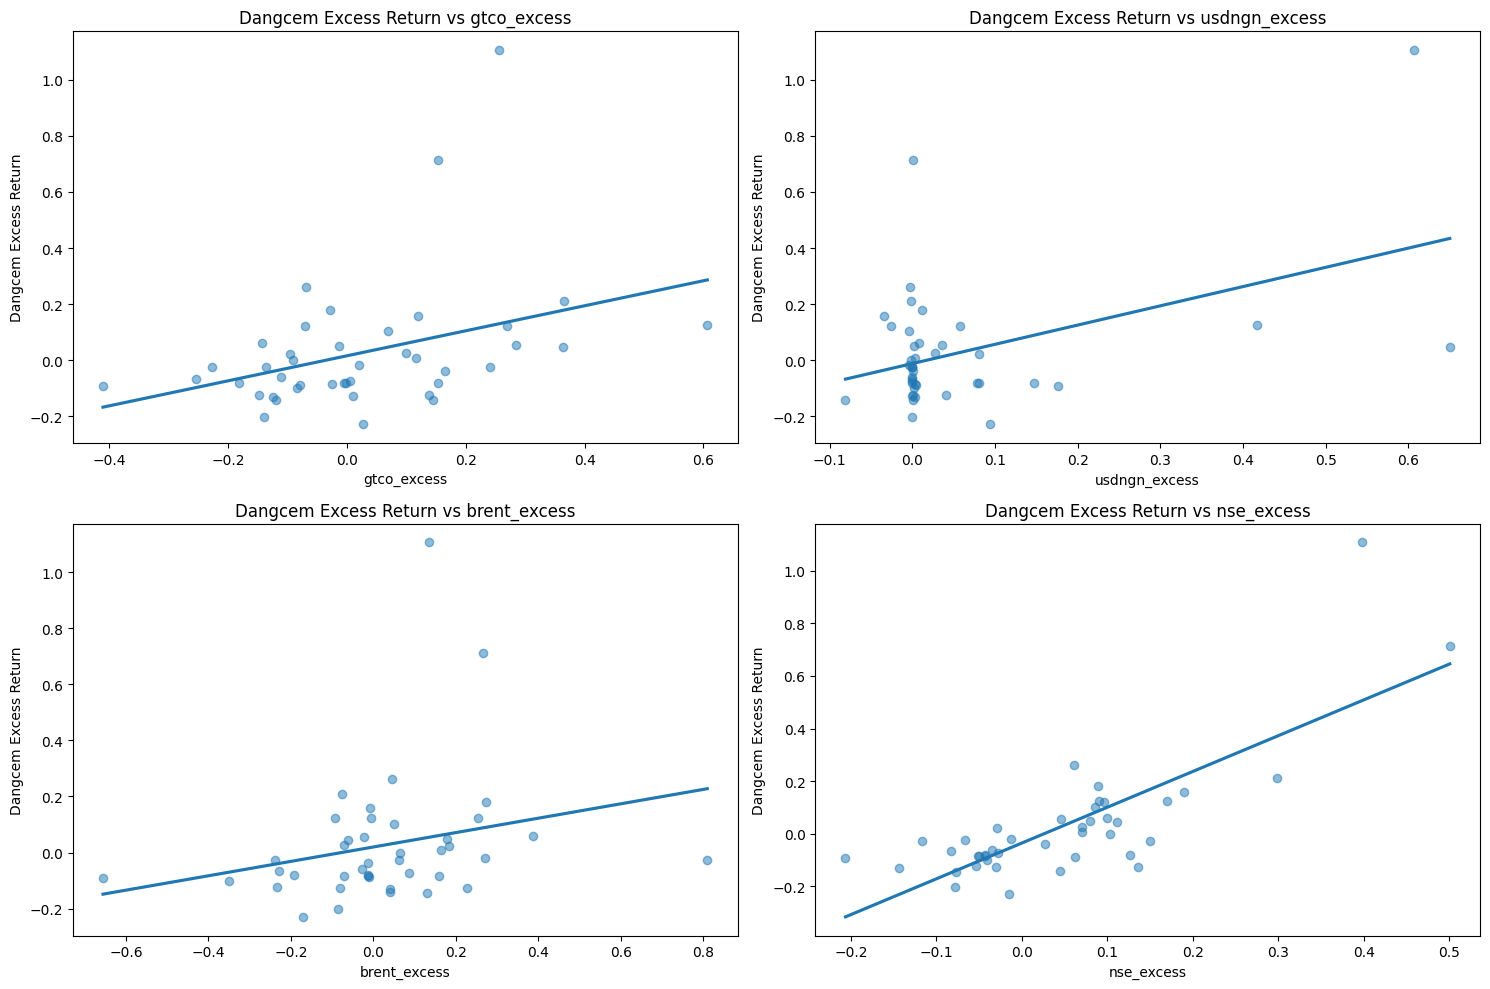

In [107]:
x_variables = ["gtco_excess", "usdngn_excess", "brent_excess", "nse_excess"]

fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(15, 10))
axes =axes.flatten()

for i, var in enumerate(x_variables):
    sns.regplot(x=var, y='dangcem_excess', data=excess_return, ax=axes[i], scatter_kws={'alpha': 0.5}, ci=None)
    axes[i].set_title(f'Dangcem Excess Return vs {var}')
    axes[i].set_xlabel(var)
    axes[i].set_ylabel('Dangcem Excess Return')

plt.tight_layout()
plt.savefig("Regressions_Plots_variables.png", dpi=300)
plt.show()

In [108]:
corr = excess_return.corr()
print("Correlations with DANGCEM excess return:")
print(corr["dangcem_excess"].sort_values(ascending=False).drop("dangcem_excess"))

Correlations with DANGCEM excess return:
nse_excess       0.787890
usdngn_excess    0.443761
gtco_excess      0.370339
brent_excess     0.250705
Name: dangcem_excess, dtype: float64


In [109]:
def correlation(x, y , **kwargs):
  coef = np.corrcoef(x, y)[0][1]
  label = r"$\rho$ = " + str(round(coef, 2))
  ax = plt.gca()
  ax.annotate(label, xy=(0.2, 0.95), size=16,
              xycoords=ax.transAxes)

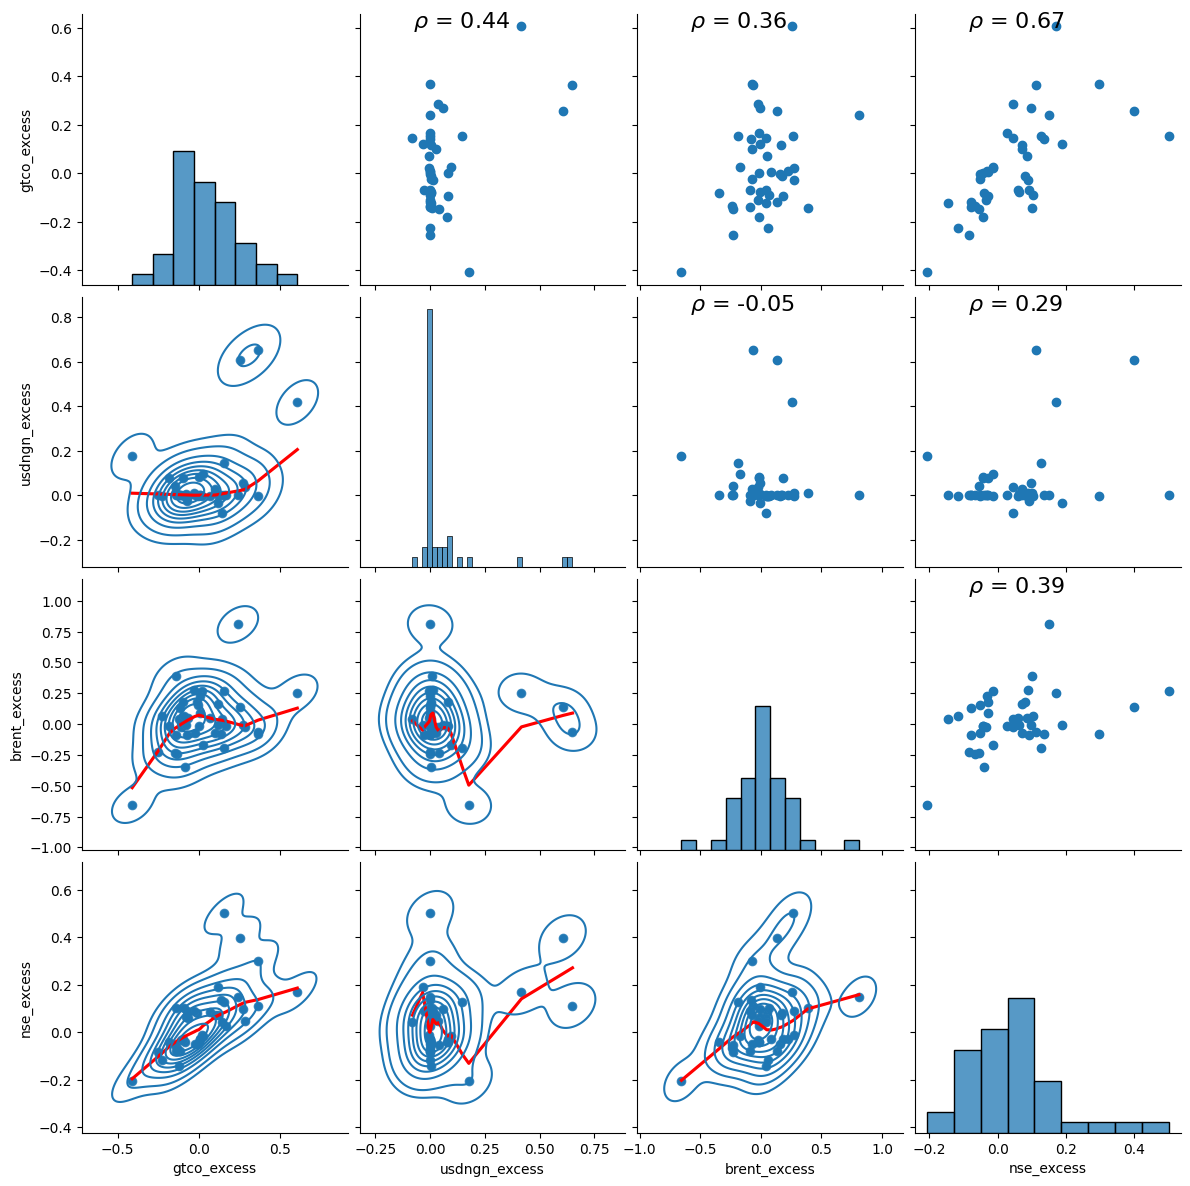

In [110]:
grid = sns.pairplot(excess_return, vars=x_variables, height=3)

grid = grid.map_upper(plt.scatter)
grid = grid.map_upper(correlation)
grid = grid.map_lower(sns.regplot, lowess=True, line_kws = {"color": "red"})
grid = grid.map_lower(sns.kdeplot)

In [111]:
result = smf.ols('dangcem_excess ~ gtco_excess + usdngn_excess + brent_excess + nse_excess', data=excess_return).fit()
print(result.summary())

                            OLS Regression Results                            
Dep. Variable:         dangcem_excess   R-squared:                       0.766
Model:                            OLS   Adj. R-squared:                  0.740
Method:                 Least Squares   F-statistic:                     30.25
Date:                Sat, 06 Jun 2026   Prob (F-statistic):           3.30e-11
Time:                        22:04:10   Log-Likelihood:                 32.642
No. Observations:                  42   AIC:                            -55.28
Df Residuals:                      37   BIC:                            -46.59
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
Intercept        -0.0680      0.021     -3.301

In [112]:
result.summary2().tables[1]

,Coef.,Std.Err.,t,P>|t|,[0.025,0.975]
Intercept,-0.068013,0.020602,-3.301293,2.138423e-03,-0.109757,-0.026270
gtco_excess,-0.547980,0.141029,-3.885587,4.077140e-04,-0.833731,-0.262228
usdngn_excess,0.561658,0.141604,3.966384,3.218603e-04,0.274740,0.848575
brent_excess,0.061446,0.092328,0.665523,5.098439e-01,-0.125628,0.248521
nse_excess,1.659657,0.189300,8.767318,1.457047e-10,1.276098,2.043217


In [113]:
X = sm.add_constant(excess_return[x_variables], prepend=True)
y = excess_return["dangcem_excess"]
model = sm.OLS(y, X)
results = model.fit()
print(results.summary())

                            OLS Regression Results                            
Dep. Variable:         dangcem_excess   R-squared:                       0.766
Model:                            OLS   Adj. R-squared:                  0.740
Method:                 Least Squares   F-statistic:                     30.25
Date:                Sat, 06 Jun 2026   Prob (F-statistic):           3.30e-11
Time:                        22:04:10   Log-Likelihood:                 32.642
No. Observations:                  42   AIC:                            -55.28
Df Residuals:                      37   BIC:                            -46.59
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
const            -0.0680      0.021     -3.301

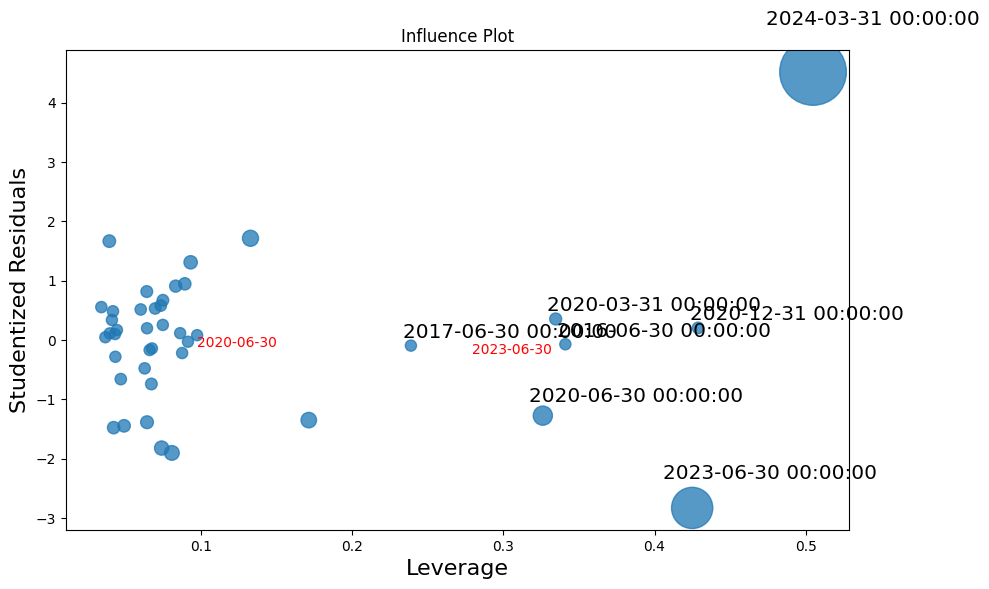

In [114]:
fig, ax = plt.subplots(figsize=(10, 6))
influence_plot(results, ax=ax, criterion="cooks")
ax.set_title("Influence Plot")
influence = results.get_influence()
cooks_d = influence.cooks_distance[0]
threshold = 4 / len(y)
outlier_idx = np.where(cooks_d > threshold)[0]
for idx in outlier_idx:
    ax.annotate(str(excess_return.index[idx].date()),
                xy=(results.fittedvalues.iloc[idx],
                    results.resid.iloc[idx]),
                fontsize=10, color="red")

plt.tight_layout()
plt.savefig("influence_plot.png", dpi=300)
plt.show()

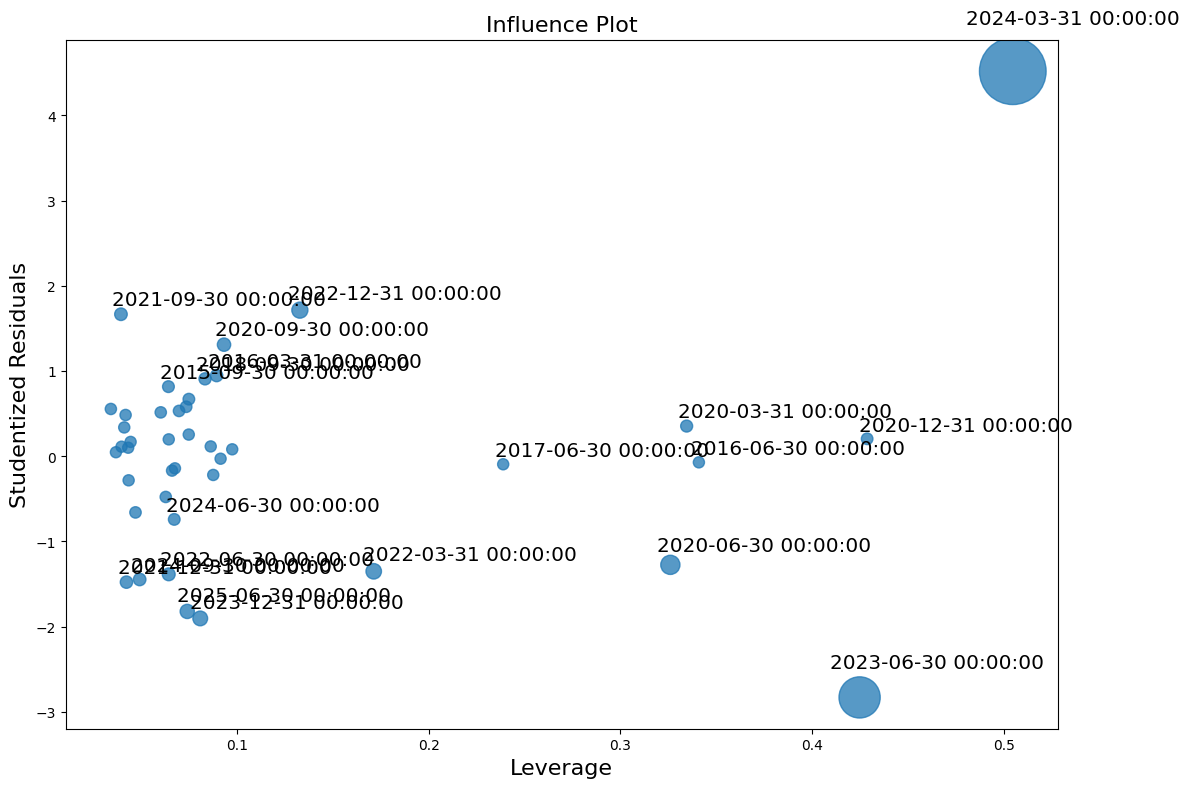

In [115]:
fig = sm.graphics.influence_plot(result, criterion="cooks", alpha=0.5)
plt.tight_layout(pad=1.0)
plt.savefig("influence_plot_1.png", dpi=300)
plt.show()

In [116]:
influence = results.get_influence()
inf_sum = influence.summary_frame().sort_values("cooks_d", ascending=False)
inf_sum.head(10)

,dfb_const,dfb_gtco_excess,dfb_usdngn_excess,dfb_brent_excess,dfb_nse_excess,cooks_d,standard_resid,hat_diag,dffits_internal,student_resid,dffits
Date,,,,,,,,,,,
2024-03-31,-1.143999,-1.938611,3.485213,0.421700,2.298371,2.729877,3.659218,0.504799,3.694507,4.518459,4.562035
2023-06-30,0.106233,-0.341331,-1.994511,0.011016,0.521503,0.995323,-2.595499,0.424871,-2.230833,-2.830827,-2.433098
2020-06-30,-0.186044,-0.082747,0.031020,-0.775153,0.161320,0.154724,-1.264341,0.326122,-0.879555,-1.274985,-0.886960
2022-12-31,0.402554,0.601528,-0.277327,-0.210864,-0.293673,0.085548,1.671251,0.132804,0.654017,1.714493,0.670939
2022-03-31,-0.092493,0.429521,-0.125005,-0.434818,-0.205502,0.073802,-1.335905,0.171341,-0.607461,-1.350706,-0.614192
2023-12-31,-0.229316,-0.157508,-0.000640,0.407783,-0.152249,0.059511,-1.839586,0.080822,-0.545487,-1.903701,-0.564499
2025-06-30,-0.298574,-0.189487,0.277691,0.308221,-0.174127,0.049940,-1.767066,0.074046,-0.499698,-1.821580,-0.515114
2020-09-30,0.251314,0.344765,-0.164446,-0.147664,-0.099621,0.034583,1.296852,0.093230,0.415833,1.309310,0.419828
2022-06-30,-0.143915,0.243238,0.021025,-0.032722,-0.238227,0.025805,-1.369313,0.064382,-0.359199,-1.386264,-0.363646


In [117]:
zenithb = pd.read_csv("/content/ZENITHB Historical Data.csv", parse_dates=True, index_col="Date")
zenithb.head()

,Price,Open,High,Low,Vol.,Change %
Date,,,,,,
01/06/2026,128.85,131.10,131.5,128.10,32.94M,-1.72%
29/05/2026,131.10,132.00,135.0,129.50,23.97M,-0.68%
26/05/2026,132.00,131.95,132.5,131.80,33.83M,0.04%
25/05/2026,131.95,132.00,132.0,131.25,37.93M,-0.04%
22/05/2026,132.00,132.00,132.0,130.55,24.39M,0.00%


In [118]:
access = pd.read_csv("/content/ACCESSCORP Historical Data.csv", parse_dates=True, index_col="Date")
access.head()

,Price,Open,High,Low,Vol.,Change %
Date,,,,,,
01/06/2026,24.00,24.00,24.85,24.0,130.26M,-0.21%
29/05/2026,24.05,24.60,24.70,24.0,133.28M,-2.24%
26/05/2026,24.60,25.00,24.90,24.2,80.61M,-1.60%
25/05/2026,25.00,24.95,25.00,24.5,61.29M,0.20%
22/05/2026,24.95,25.00,25.30,24.6,69.67M,-1.38%


In [119]:
zenithb = price_column_change(zenithb)
zenithb.columns = ["zenithb_close"]
zenithb.head()

,zenithb_close
Date,
01/06/2026,128.85
29/05/2026,131.10
26/05/2026,132.00
25/05/2026,131.95
22/05/2026,132.00


In [120]:
access = price_column_change(access)
access.columns = ["access_close"]
access.head()

,access_close
Date,
01/06/2026,24.00
29/05/2026,24.05
26/05/2026,24.60
25/05/2026,25.00
22/05/2026,24.95


In [121]:
df2 = pd.concat([zenithb, access], axis=1)
df2.head()

,zenithb_close,access_close
Date,,
01/06/2026,128.85,24.00
29/05/2026,131.10,24.05
26/05/2026,132.00,24.60
25/05/2026,131.95,25.00
22/05/2026,132.00,24.95


In [122]:
df2.reset_index(inplace=True)
df2.head()

,Date,zenithb_close,access_close
0,01/06/2026,128.85,24.00
1,29/05/2026,131.10,24.05
2,26/05/2026,132.00,24.60
3,25/05/2026,131.95,25.00
4,22/05/2026,132.00,24.95


In [123]:
df2["Date"] = pd.to_datetime(df2["Date"], dayfirst=True)
df2.head()

,Date,zenithb_close,access_close
0,2026-06-01,128.85,24.00
1,2026-05-29,131.10,24.05
2,2026-05-26,132.00,24.60
3,2026-05-25,131.95,25.00
4,2026-05-22,132.00,24.95


In [124]:
df2.set_index("Date", inplace=True)
df2.head()

,zenithb_close,access_close
Date,,
2026-06-01,128.85,24.00
2026-05-29,131.10,24.05
2026-05-26,132.00,24.60
2026-05-25,131.95,25.00
2026-05-22,132.00,24.95


In [125]:
df2_quart = df2.resample("QE").last()

In [126]:
df2_quart.head()

,zenithb_close,access_close
Date,,
2015-06-30,19.25,NaN
2015-09-30,16.81,NaN
2015-12-31,14.05,NaN
2016-03-31,10.75,NaN
2016-06-30,15.77,NaN


In [127]:
df2_quart.isnull().sum()

,0
zenithb_close,0
access_close,27


In [128]:
df2_quart.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 45 entries, 2015-06-30 to 2026-06-30
Freq: QE-DEC
Data columns (total 2 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   zenithb_close  45 non-null     float64
 1   access_close   18 non-null     float64
dtypes: float64(2)
memory usage: 1.1 KB


In [129]:
df2_quart.fillna(0, inplace=True)

In [130]:
df2_quart.isnull().sum()

,0
zenithb_close,0
access_close,0


In [131]:
return_1 = df2_quart.pct_change().dropna()

In [132]:
return_1.head()

,zenithb_close,access_close
Date,,
2022-03-31,-0.109344,inf
2022-06-30,-0.031250,-0.051282
2022-09-30,-0.081567,-0.129730
2022-12-31,0.200201,0.055901
2023-03-31,0.076923,0.058824


In [133]:
return_1.tail()

,zenithb_close,access_close
Date,,
2025-06-30,0.211702,-0.011186
2025-09-30,0.211589,0.160633
2025-12-31,-0.104348,-0.181287
2026-03-31,0.550162,0.230952
2026-06-30,0.344990,-0.071567


In [134]:
excess_return["zenithb_excess"] = return_1["zenithb_close"] - t_bill_91D_quart["91_Day_TBILL"]
excess_return["access_excess"] = return_1["access_close"] - t_bill_91D_quart["91_Day_TBILL"]

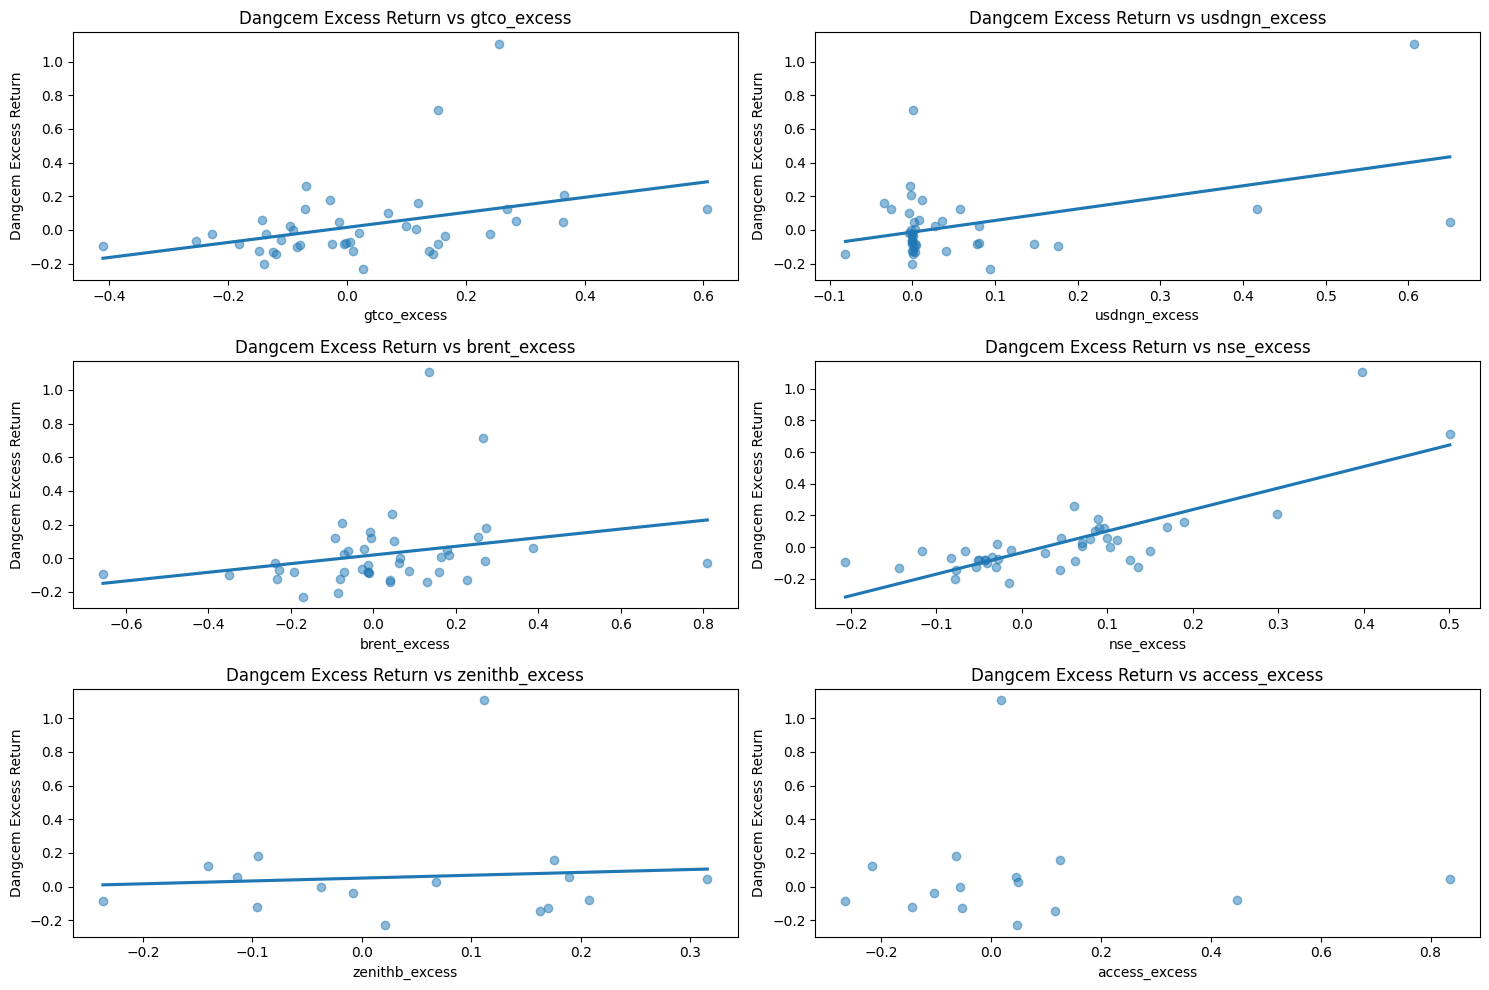

In [135]:
x_variables_extra = ["gtco_excess", "usdngn_excess", "brent_excess", "nse_excess","zenithb_excess", "access_excess"]

fig, axes = plt.subplots(nrows=3, ncols=2, figsize=(15, 10))
axes =axes.flatten()

for i, var in enumerate(x_variables_extra):
    sns.regplot(x=var, y='dangcem_excess', data=excess_return, ax=axes[i], scatter_kws={'alpha': 0.5}, ci=None)
    axes[i].set_title(f'Dangcem Excess Return vs {var}')
    axes[i].set_xlabel(var)
    axes[i].set_ylabel('Dangcem Excess Return')

plt.tight_layout()
plt.savefig("Regressions_Plots_variables_extra.png", dpi=300)
plt.show()

In [136]:
excess_return.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 42 entries, 2015-09-30 to 2025-12-31
Freq: QE-DEC
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   dangcem_excess  42 non-null     float64
 1   gtco_excess     42 non-null     float64
 2   usdngn_excess   42 non-null     float64
 3   brent_excess    42 non-null     float64
 4   nse_excess      42 non-null     float64
 5   zenithb_excess  16 non-null     float64
 6   access_excess   16 non-null     float64
dtypes: float64(7)
memory usage: 2.6 KB


In [137]:
corr_2 = excess_return.corr()
print("Correlations with DANGCEM excess return + extra variable:")
print(corr_2["dangcem_excess"].sort_values(ascending=False).drop("dangcem_excess"))

Correlations with DANGCEM excess return + extra variable:
nse_excess        0.787890
usdngn_excess     0.443761
gtco_excess       0.370339
brent_excess      0.250705
zenithb_excess    0.086971
access_excess    -0.012257
Name: dangcem_excess, dtype: float64


In [138]:
excess_return_2 = excess_return

In [139]:
excess_return_2.head()

,dangcem_excess,gtco_excess,usdngn_excess,brent_excess,nse_excess,zenithb_excess,access_excess
Date,,,,,,,
2015-09-30,-0.025006,-0.136391,0.000000,-0.239346,-0.066924,NaN,NaN
2015-12-31,-0.066737,-0.253734,0.000101,-0.229274,-0.082502,NaN,NaN
2016-03-31,-0.026488,-0.226969,-0.001005,0.062232,-0.116472,NaN,NaN
2016-06-30,0.124038,0.606393,0.417103,0.254545,0.169586,NaN,NaN
2016-09-30,-0.080174,-0.001485,0.080860,-0.012480,-0.042651,NaN,NaN


In [140]:
excess_return_2.dropna(inplace=True)
excess_return_2.head()

,dangcem_excess,gtco_excess,usdngn_excess,brent_excess,nse_excess,zenithb_excess,access_excess
Date,,,,,,,
2022-03-31,0.059856,-0.142808,0.008623,0.387375,0.099471,-0.113691,inf
2022-06-30,-0.000487,-0.090793,-0.001156,0.063942,0.103312,-0.037221,-0.057253
2022-09-30,-0.122998,-0.148054,0.041228,-0.233865,-0.053909,-0.095474,-0.143637
2022-12-31,0.054604,0.285073,0.036377,-0.023306,0.045425,0.189499,0.045199
2023-03-31,0.025091,0.099304,0.027392,-0.071470,0.070377,0.067531,0.049432


In [141]:
excess_return_2.replace([np.inf, -np.inf], np.nan, inplace=True)
excess_return_2.dropna(inplace=True)
model_2 = smf.ols('dangcem_excess ~ gtco_excess + usdngn_excess + brent_excess + nse_excess + zenithb_excess + access_excess', data=excess_return_2).fit()
print(model_2.summary())

                            OLS Regression Results                            
Dep. Variable:         dangcem_excess   R-squared:                       0.934
Model:                            OLS   Adj. R-squared:                  0.885
Method:                 Least Squares   F-statistic:                     18.97
Date:                Sat, 06 Jun 2026   Prob (F-statistic):           0.000250
Time:                        22:04:15   Log-Likelihood:                 17.085
No. Observations:                  15   AIC:                            -20.17
Df Residuals:                       8   BIC:                            -15.21
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
Intercept         -0.1569      0.044     -3.

In [142]:
model_2.summary2().tables[1]

,Coef.,Std.Err.,t,P>|t|,[0.025,0.975]
Intercept,-0.156912,0.044016,-3.564914,0.007348,-0.258413,-0.055412
gtco_excess,0.568355,0.525794,1.080947,0.311226,-0.644127,1.780837
usdngn_excess,0.550771,0.272257,2.022983,0.077698,-0.077055,1.178596
brent_excess,0.205460,0.295677,0.694880,0.506807,-0.476372,0.887292
nse_excess,1.998410,0.473936,4.216627,0.002929,0.905512,3.091308
zenithb_excess,-0.744124,0.760100,-0.978981,0.356262,-2.496918,1.008670
access_excess,-0.351284,0.278507,-1.261310,0.242733,-0.993522,0.290955


In [143]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

In [144]:
labels = [
    "Intercept", "gtco_excess", "usdngn_excess", "brent_excess", "nse_excess", "zenithb_excess", "access_excess"
]

In [145]:
variables = model_2.model.exog
vif = [variance_inflation_factor(variables, i) for i in range(variables.shape[1])]
vif_data = pd.DataFrame({"Variable": labels, "VIF": vif})
vif_data

,Variable,VIF
0,Intercept,2.582850
1,gtco_excess,8.911231
2,usdngn_excess,4.470295
3,brent_excess,1.787633
4,nse_excess,3.331051
5,zenithb_excess,17.135615
6,access_excess,7.259040


In [146]:
high_vif = vif_data[vif_data["VIF"] > 5]["Variable"].to_list()
print(high_vif)

['gtco_excess', 'zenithb_excess', 'access_excess']


In [147]:
excess_return_3 = excess_return.drop(columns=['zenithb_excess', 'access_excess'])

In [148]:
excess_return_3.head()

,dangcem_excess,gtco_excess,usdngn_excess,brent_excess,nse_excess
Date,,,,,
2022-06-30,-0.000487,-0.090793,-0.001156,0.063942,0.103312
2022-09-30,-0.122998,-0.148054,0.041228,-0.233865,-0.053909
2022-12-31,0.054604,0.285073,0.036377,-0.023306,0.045425
2023-03-31,0.025091,0.099304,0.027392,-0.071470,0.070377
2023-06-30,0.046018,0.363011,0.650074,-0.061051,0.111384


In [149]:
X_new = excess_return_3.drop(columns=["dangcem_excess"])

In [150]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

In [151]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_new)

In [152]:
pca = PCA()
pca.fit(X_scaled)

PCA()

In [153]:
explained = pca.explained_variance_ratio_
cummulative = np.cumsum(explained)

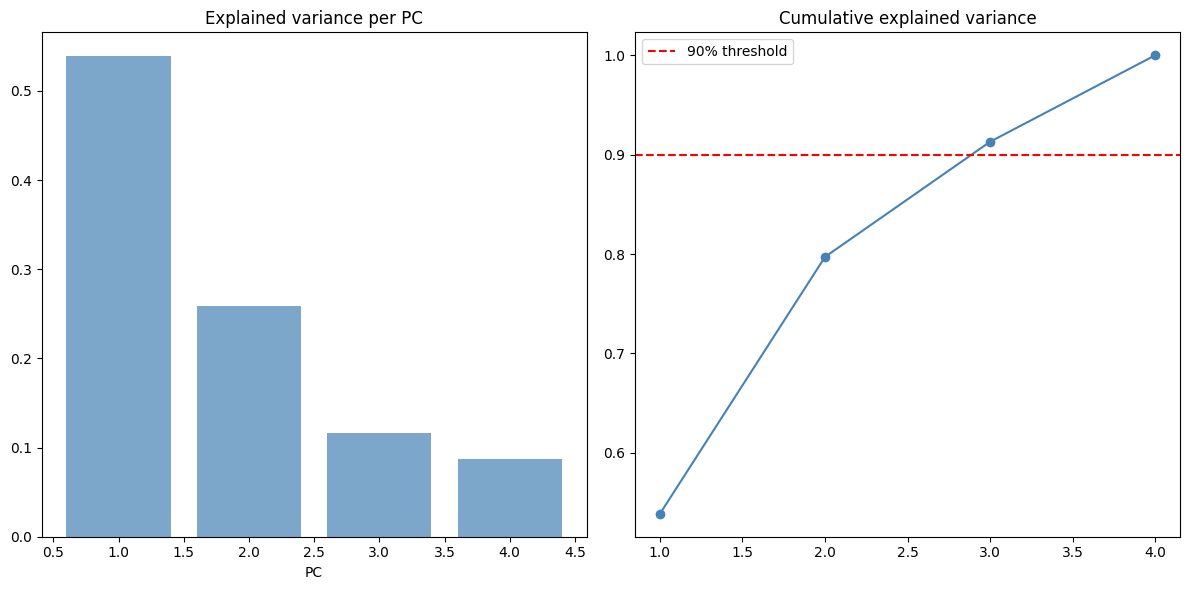

PCs needed for 90% variance: 3


In [154]:
fig, axes = plt.subplots(1, 2, figsize=(12, 6))
axes[0].bar(range(1, len(explained)+1), explained, color="steelblue", alpha=0.7)
axes[0].set_title("Explained variance per PC"); axes[0].set_xlabel("PC")
axes[1].plot(range(1, len(cummulative)+1), cummulative, "o-", color="steelblue")
axes[1].axhline(0.9, color="red", linestyle="--", label="90% threshold")
axes[1].set_title("Cumulative explained variance")
axes[1].legend()
plt.tight_layout()
plt.savefig("pca_scree.png", dpi=150)
plt.show()

n_90 = np.argmax(cummulative >= 0.9) + 1
print(f"PCs needed for 90% variance: {n_90}")

PCA Loadings:
                 PC1    PC2    PC3    PC4
gtco_excess    0.527 -0.354  0.750 -0.187
usdngn_excess  0.542 -0.329 -0.643 -0.430
brent_excess   0.291  0.852  0.092 -0.425
nse_excess     0.587  0.199 -0.125  0.775

Highest loading in PC1: nse_excess


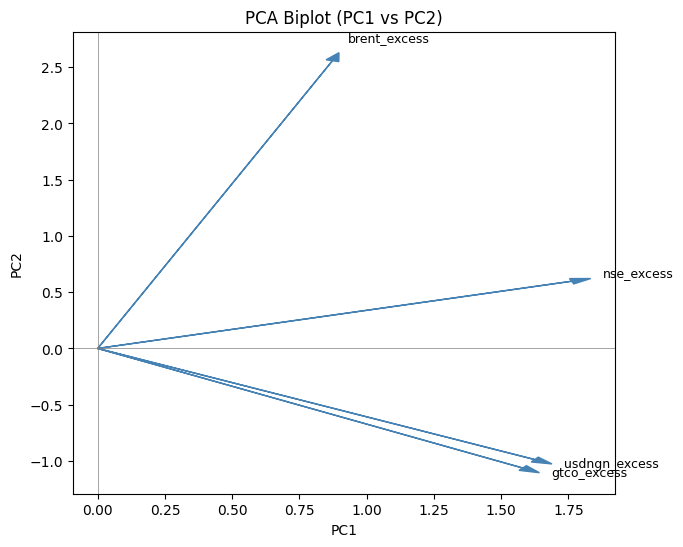

In [155]:
loadings = pd.DataFrame(
    pca.components_.T,
    index=X_new.columns,
    columns=[f"PC{i+1}" for i in range(pca.n_components_)]
)
print("PCA Loadings:")
print(loadings.round(3))

# PC1 dominant variable
pc1_dominant = loadings["PC1"].abs().idxmax()
print(f"\nHighest loading in PC1: {pc1_dominant}")

# Biplot (optional but informative)
plt.figure(figsize=(7, 6))
for i, var in enumerate(X_new.columns):
    plt.arrow(0, 0, pca.components_[0,i]*3,
              pca.components_[1,i]*3,
              head_width=0.05, color="steelblue")
    plt.text(pca.components_[0,i]*3.2,
             pca.components_[1,i]*3.2, var, fontsize=9)
plt.xlabel("PC1"); plt.ylabel("PC2")
plt.title("PCA Biplot (PC1 vs PC2)")
plt.axhline(0, color="grey", linewidth=0.5)
plt.axvline(0, color="grey", linewidth=0.5)
plt.savefig("pca_biplot.png", dpi=150)
plt.show()

In [156]:
# Option A: PCR (Principal Components Regression)
X_pca = pca.transform(X_scaled)[:, :n_90]
pc_cols = [f"PC{i+1}" for i in range(n_90)]
X_pcr = sm.add_constant(
    pd.DataFrame(X_pca, index=excess_return_3.index, columns=pc_cols)
)
model_pcr = sm.OLS(excess_return_3["dangcem_excess"], X_pcr).fit()
print("PCR Summary:")
print(model_pcr.summary())

# Option B: PCA-informed variable selection
# Keep variables with |loading| > 0.3 in PC1
keep_vars = loadings[loadings["PC1"].abs() > 0.3].index.tolist()
print(f"\nVariables kept by PCA guidance: {keep_vars}")
X_guided = sm.add_constant(excess_return_3[keep_vars])
model_guided = sm.OLS(excess_return_3["dangcem_excess"], X_guided).fit()
print(model_guided.summary())

PCR Summary:
                            OLS Regression Results                            
Dep. Variable:         dangcem_excess   R-squared:                       0.792
Model:                            OLS   Adj. R-squared:                  0.735
Method:                 Least Squares   F-statistic:                     13.93
Date:                Sat, 06 Jun 2026   Prob (F-statistic):           0.000459
Time:                        22:04:16   Log-Likelihood:                 8.4244
No. Observations:                  15   AIC:                            -8.849
Df Residuals:                      11   BIC:                            -6.017
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0581      0.042      1

In [157]:
from scipy import stats

brent = excess_return_3["brent_excess"].copy()

# Shift to positive for Box-Cox
shift = abs(brent.min()) + 1
brent_shifted = brent + shift
brent_bc, lambda_bc = stats.boxcox(brent_shifted)

print(f"Optimal lambda: {lambda_bc:.4f}")
# lambda ≈ 1 → no transformation needed
# lambda ≈ 0 → log transform appropriate
# lambda ≈ 0.5 → square root

# Compare normality: Shapiro-Wilk
sw_orig = stats.shapiro(brent)
sw_bc   = stats.shapiro(brent_bc)
print(f"Shapiro-Wilk (original): stat={sw_orig.statistic:.4f}, p={sw_orig.pvalue:.4f}")
print(f"Shapiro-Wilk (Box-Cox):  stat={sw_bc.statistic:.4f},  p={sw_bc.pvalue:.4f}")

# Re-run OLS with transformed Brent
excess_return_3["BRENT_BC"] = brent_bc
X_bc = sm.add_constant(excess_return_3[['gtco_excess', 'usdngn_excess',
       'nse_excess', "BRENT_BC"]])
model_bc = sm.OLS(excess_return_3["dangcem_excess"], X_bc).fit()
print(f"\nAIC before: {results.aic:.2f} → after Box-Cox: {model_bc.aic:.2f}")

Optimal lambda: -1.0470
Shapiro-Wilk (original): stat=0.9566, p=0.6337
Shapiro-Wilk (Box-Cox):  stat=0.9769,  p=0.9441

AIC before: -55.28 → after Box-Cox: -10.34


In [158]:
fitted_ret = results.fittedvalues + t_bill_91D_quart['91_Day_TBILL'].reindex(results.fittedvalues.index)
mean = fitted_ret.mean()
std = results.resid.std()

month_mean = (1 + mean) ** (1/3) -1
month_std = std / np.sqrt(3)

print (f"Quarterly mean return: {mean:.4f}({mean * 100:.2f}%)")
print (f"Quarterly std: {std:.4f}({std * 100:.2f}%)")
print (f"Monthly mean return: {month_mean:.4f}({month_mean * 100:.2f}%)")
print (f"Monthly std: {month_std:.4f}({month_std * 100:.2f}%)")

Quarterly mean return: 0.0478(4.78%)
Quarterly std: 0.1126(11.26%)
Monthly mean return: 0.0157(1.57%)
Monthly std: 0.0650(6.50%)


In [160]:
np.random.seed(42)
simulation = 10_000
month = 12
monthly_invest = 10_000

monthly_ret = np.random.normal(month_mean, month_std, size=(simulation, month))

portfolio = np.zeros((simulation, month + 1))

for i in range(1, month + 1):
  portfolio[:, i] = ((portfolio[:, i-1] + monthly_invest) * (1 + monthly_ret[:, i-1]))
final_val = portfolio[:, i]

print(f" Expected final value(mean): {final_val.mean():.2f}")
print(f" Expected final percentile(95th): {np.percentile(final_val, 95):.2f}")
print(f" Expected final percentile(5th): {np.percentile(final_val, 5):.2f}")
print(f" Probability of loss: {(final_val < 120_000).mean()*100:.2f}%")

 Expected final value(mean): 133157.60
 Expected final percentile(95th): 166535.31
 Expected final percentile(5th): 104697.55
 Probability of loss: 25.30%


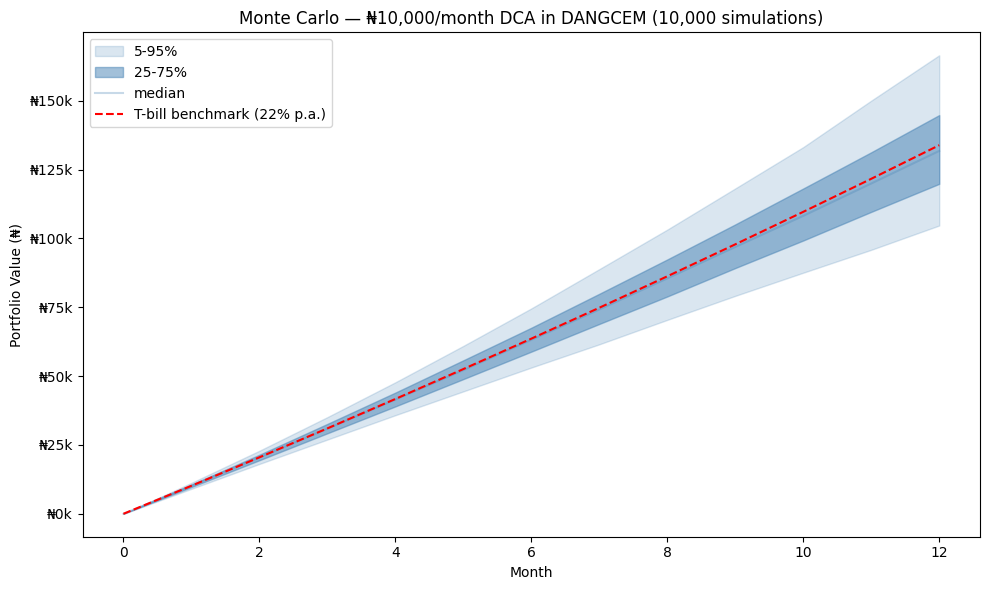

In [162]:
months = np.arange(0, month + 1)

pct_5 = np.percentile(portfolio, 5, axis=0)
pct_25 = np.percentile(portfolio, 25, axis=0)
pct_50 = np.percentile(portfolio, 50, axis=0)
pct_75 = np.percentile(portfolio, 75, axis=0)
pct_95 = np.percentile(portfolio, 95, axis=0)

fig, ax = plt.subplots(figsize=(10, 6))
ax.fill_between(months, pct_5, pct_95, color="steelblue", alpha=0.2, label = "5-95%")
ax.fill_between(months, pct_25, pct_75, color="steelblue", alpha=0.5, label = "25-75%")
ax.plot(months, pct_50, color ="steelblue", alpha=0.3, label="median")

# T-bill deterministic benchmark
tbill_rate_m = (1 + 0.22) ** (1/12) - 1
tbill_path = np.array(
    [monthly_invest * ((1+tbill_rate_m)**k - 1) / tbill_rate_m * (1+tbill_rate_m)
     for k in range(month +1)]
)
ax.plot(months, tbill_path, "r--", linewidth=1.5, label="T-bill benchmark (22% p.a.)")

ax.set_xlabel("Month"); ax.set_ylabel("Portfolio Value (₦)")
ax.set_title("Monte Carlo — ₦10,000/month DCA in DANGCEM (10,000 simulations)")
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x,_: f"₦{x/1000:.0f}k"))
ax.legend(); plt.tight_layout()
plt.savefig("montecarlo_fan.png", dpi=150)

In [164]:
tbill_final = tbill_path[-1]

comparison = pd.DataFrame({
    "Scenario": ["T-bill (deterministic)", "DANGCEM 5th pct (worst case)",
                 "DANGCEM median", "DANGCEM 95th pct (best case)"],
    "Final Portfolio (₦)": [
        tbill_final,
        np.percentile(final_val, 5),
        np.percentile(final_val, 50),
        np.percentile(final_val, 95)
    ]
})
comparison["Total Invested"]  = 120_000
comparison["Return (₦)"]      = comparison["Final Portfolio (₦)"] - 120_000
comparison["Return (%)"]      = (comparison["Return (₦)"] / 120_000 * 100).round(1)
comparison["Final Portfolio (₦)"] = comparison["Final Portfolio (₦)"].round(0)

print(comparison.to_string(index=False))
comparison.to_csv("comparison.csv", index=False)

                    Scenario  Final Portfolio (₦)  Total Invested    Return (₦)  Return (%)
      T-bill (deterministic)             133866.0          120000  13865.854131        11.6
DANGCEM 5th pct (worst case)             104698.0          120000 -15302.454744       -12.8
              DANGCEM median             131786.0          120000  11785.558029         9.8
DANGCEM 95th pct (best case)             166535.0          120000  46535.307467        38.8
